In [5]:
import os
import nibabel as nib
import numpy as np 
from collections import OrderedDict
import json
from pathlib import Path

from utils.helper import convert_nrrd_to_nifti, create_folder, plot_all_slices, plot_histogram, generate_binary_image, adjust_affine_for_spacing_and_origin, save_binary_image_with_adjusted_origin, make_if_dont_exist

In [6]:

# define dataset path
BASE_PATH = Path('./').resolve()
DATA_PATH = BASE_PATH / 'dataset'
# ORG_DATA_PATH = Path('/work/shared/ngmm/3Dimage/Analysed_brains/Wdr47Kusss').resolve()
# ORG_SEG_DATA_PATH = Path('/work/shared/ngmm/scripts/Taiabur/seg.data').resolve()

project_name = 'Wdr47Kusss' #change here for different task name
task_name = 'Dataset001_' + project_name 

TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTr'
# GT_TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTr'
# TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTs'
# GT_TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTs'
# PREDICTION_RESULTS_PATH  = BASE_PATH / 'dataset/nnUNet_Prediction_Results' / task_name
# TASK_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name 

# setup environment variables
nnUNet_raw = BASE_PATH / 'dataset/nnUNet_raw_data'
nnUNet_preprocessed = BASE_PATH / 'dataset/nnUNet_preprocessed'
nnUNet_results = BASE_PATH / 'dataset/nnUNet_results'

In [7]:
import nibabel as nib
import numpy as np

def multiply_nifti_images(image_path1, image_path2, output_path):
    """
    Load two NIfTI images, multiply them, and save the result.
    
    Parameters:
        image_path1 (str): The file path to the first NIfTI image.
        image_path2 (str): The file path to the second NIfTI image.
        output_path (str): The file path to save the multiplied image.
    """
    # Load the NIfTI images
    img1 = nib.load(image_path1)
    img2 = nib.load(image_path2)
    
    # Get the image data as numpy arrays
    data1 = img1.get_fdata()
    data2 = img2.get_fdata()
    
    # Multiply the images
    result_data = data1 * data2
    
    # Create a new NIfTI image from the result
    result_img = nib.Nifti1Image(result_data, img1.affine, img1.header)
    
    # Extract the file name
    file_name = os.path.basename(image_path1)

    output_path = os.path.join(output_path,file_name)

    # Save the result
    nib.save(result_img, output_path)

In [8]:
prediction_images = nnUNet_results / task_name / 'nnUNetTrainer__nnUNetPlans__2d' / 'crossval_results_folds_0_1_2_3_4'
output_path = '/work/shared/ngmm/scripts/Taiabur/dataset/postprocess_results'

for img in os.listdir(prediction_images):
    if img.endswith('.nii.gz'):
        image_path1 = prediction_images / img
        image_path2 = TRAINING_DATASET_PATH / img.replace('.nii.gz','_0000.nii.gz')
        multiply_nifti_images(image_path1, image_path2, output_path)
print('done...')

done...


In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG2561_RCL5_0000.nii.gz'
# nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/NG2561_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Display the slice
    ax = axes[0]
    ax.imshow(data[:, :, slice_no], cmap='gray')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Pixel Intensity Distribution')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=200, description='Slice', max=400), Output()), _dom_classes=('widget-int…

In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = 'dataset/nnUNet_test_data_gt/binary/NG2561_RC_masked_0000.nii.gz'
# nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/NG2561_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Display the slice
    ax = axes[0]
    ax.imshow(data[:, :, slice_no], cmap='gray')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Pixel Intensity Distribution')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=401, description='Slice', max=801), Output()), _dom_classes=('widget-int…

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/3d_fullres/NG2561_RCL5.nii.gz'
# nifti_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/NG2561_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Display the slice
    ax = axes[0]
    ax.imshow(data[:, :, slice_no], cmap='gray')
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Pixel Intensity Distribution')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=200, description='Slice', max=400), Output()), _dom_classes=('widget-int…

(603, 734, 401)


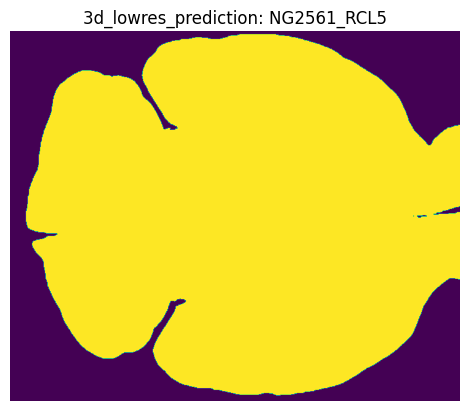

In [10]:
import nibabel as nib
import matplotlib.pyplot as plt
postporcess_vol =  '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_postprocessed/3d_lowres/NG2561_RCL5.nii.gz'
rc_vol = ''

image_pp_data = nib.load(postporcess_vol).get_fdata()
print(image_pp_data.shape)
plt.imshow(image_pp_data[:,:,200])
plt.title('3d_lowres_prediction: NG2561_RCL5')
plt.axis('off')
plt.show()


In [4]:
import numpy as np
import nibabel as nib
import nrrd

def dice_score(y_true, y_pred):
    """
    Calculate the Dice Score.
    
    Parameters:
    - y_true: numpy.ndarray, the ground truth binary mask.
    - y_pred: numpy.ndarray, the predicted binary mask.
    
    Returns:
    - dice: float, the Dice score.
    """
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred))

def load_nifti_file(filepath):
    """
    Load a NIfTI file and return a numpy array.
    
    Parameters:
    - filepath: str, the path to the .nii or .nii.gz file.
    
    Returns:
    - numpy.ndarray, the loaded image data.
    """
    nifti_img = nib.load(filepath)
    return nifti_img.get_fdata(), nifti_img.affine

def load_nrrd_file(nrrd_path):
    data, header = nrrd.read(nrrd_path)
    return data, header

def display_slice(img_data, slice_no=None):
    if slice_no is None:
        slice_no = img_data.shape[2] // 2  # Mid-slice if not specified
    plt.imshow(img_data[:, :, slice_no].T, cmap="gray", origin="lower")
    plt.title(f"Shape {img_data.shape}, Slice: {slice_no}" )
    plt.axis('off')
    plt.show()



In [4]:

# Paths to your NIfTI files
ground_truth_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data_gt/binary/NG2561_RC_masked_0000.nii.gz'

prediction_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_postprocessed/3d_lowres/NG2561_RCL5.nii.gz'

# Load the images
gt_data, gt_affine = load_nifti_file(ground_truth_path)
print(gt_data.shape)
# display_slice(gt_data,gt_data.shape[2]//2)
prediction_data, pre_affine = load_nifti_file(prediction_path)
print(prediction_data.shape)

# # Ensure the predictions are binary (this step may vary based on your prediction output)
# y_pred_binary = (y_pred > 0.5).astype(np.int)

# # Calculate the Dice Score
# score = dice_score(y_true, y_pred_binary)
# print(f"Dice Score: {score}")

# display_slice(prediction_data,prediction_data.shape[2]//2)


(1174, 1468, 802)
(603, 734, 401)


(1174, 1468, 802)


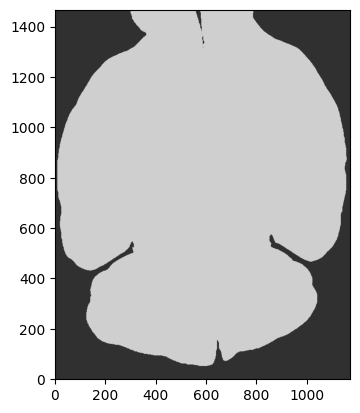

In [31]:
from scipy.ndimage import zoom
zoom_factors = [gt_data.shape[0] / prediction_data.shape[0], gt_data.shape[1] / prediction_data.shape[1], gt_data.shape[2] / prediction_data.shape[2]]

# Upsample 
prediction_data_upsampled = zoom(prediction_data, zoom_factors, order=3)  # order=3 for cubic interpolation

print(prediction_data_upsampled.shape)
display_slice(prediction_data_upsampled)

In [16]:
rc= '/work/shared/ngmm/3Dimage/Analysed_brains/Zbtb20/NG2561_RC.nrrd'
# Load the images
rc_data, rc_af = load_nrrd_file(rc)
print(rc_data.shape)

(3019, 3671, 2007)


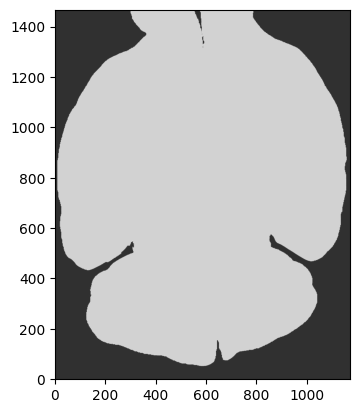

In [8]:
pred_g =  gt_data * prediction_data_upsampled
display_slice(pred_g)

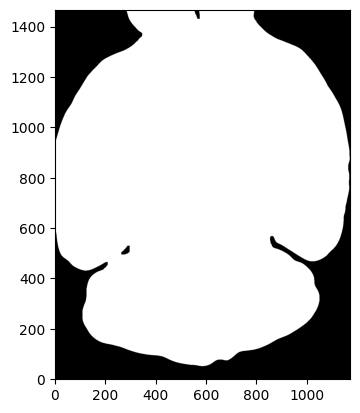

In [9]:
display_slice(gt_data)

In [22]:
upsampled_img = nib.Nifti1Image(prediction_data_upsampled, pre_affine)

# Save the upsampled image
nib.save(prediction_data_upsampled, '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/UPsampled/NG2561_RC_PRED_UP_masked_0000.nii.gz')

AttributeError: 'numpy.ndarray' object has no attribute 'to_filename'

In [3]:
# Load the images
l5_data, l5_affine = load_nifti_file('/work/shared/ngmm/3Dimage/DL_test/NG4118_L5.nii.gz')
print(l5_data.shape)

(874, 439, 338)


In [4]:
# Load the images
_data, _affine = load_nifti_file('/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG2561_RCL5_0000.nii.gz')
print(_data.shape)

(603, 734, 401)


In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt

def segment_label(nrrd_path, plot):
    data, header = load_nrrd_file(nrrd_path)

    segments = {}
    for key, value in header.items():
        if key.startswith("Segment") and key.endswith("_Name"):
            segment_number = int(''.join(filter(str.isdigit, key)))
            if 0 <= segment_number <= 24:
                segments[key] = value
    if plot:
        display_slice(data)
    
    return segments

def seg_file_list(ORG_DATA_PATH):
    all_files = os.listdir(ORG_DATA_PATH)
    seg_data = []
    for file in all_files:
        if file.endswith("Segments.seg.nrrd"):
            file_path = os.path.join(ORG_DATA_PATH, file)
            headerdata = segment_label(file_path, plot=False)
            # Append the file name and its segments as a single entry
            seg_data.append({'file': file, 'segments': headerdata})
    
    # Convert to DataFrame
    df = pd.DataFrame(seg_data)
    
    # Save to Excel
    excel_path = os.path.join('/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/data', 'segmented_data.xlsx')
    df.to_excel(excel_path, index=False)
    
    return excel_path  

nrrd_path = '/work/shared/ngmm/3Dimage/Analysed_brains/HCFC1/'
data = seg_file_list(nrrd_path)

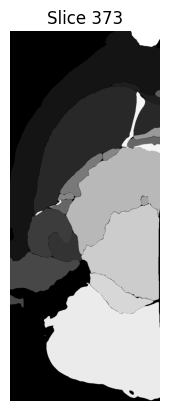

In [11]:
nrrd_path = '/work/shared/ngmm/3Dimage/Analysed_brains/HCFC1/NG4108_Segments.seg.nrrd'
header = segment_label(nrrd_path,plot=True)

In [8]:
nrrd_path = '/work/shared/ngmm/3Dimage/DL_test/Segments/NG4109_Segments4.nrrd'
header = segment_label(nrrd_path,plot=False)
print(header.items())

dict_items([('Segment0_Name', 'CTX'), ('Segment10_Name', 'st'), ('Segment11_Name', 'ic'), ('Segment12_Name', 'och'), ('Segment13_Name', 'ac'), ('Segment14_Name', 'fr'), ('Segment15_Name', 'Hb'), ('Segment16_Name', 'TH'), ('Segment17_Name', 'HY'), ('Segment18_Name', 'MB'), ('Segment19_Name', 'P'), ('Segment1_Name', 'cc+'), ('Segment20_Name', 'MY'), ('Segment21_Name', 'TCB'), ('Segment22_Name', 'V'), ('Segment23_Name', 'OB'), ('Segment2_Name', 'CPu'), ('Segment3_Name', 'DG'), ('Segment4_Name', 'HP'), ('Segment5_Name', 'RHP'), ('Segment6_Name', 'A'), ('Segment7_Name', 'ig'), ('Segment8_Name', 'fi'), ('Segment9_Name', 'f')])


In [75]:

# Initialize a list to hold the results
results = []

# Specific keys to look for
key_names = [f"Segment{i}_Name" for i in range(25)]
key_colors = ["Segment0_Color"]

# Combine the lists of keys we are interested in
keys_of_interest = key_names + key_colors

# Iterate over the OrderedDict and extract the keys of interest
for key in keys_of_interest:
    if key in data:
        # Append both key and value to the results list
        results.append((key, data[key]))

# Display the results
for key, value in results:
    print(f"{key}: {value}")


KeyboardInterrupt: 

In [22]:
import nibabel as nib
import matplotlib.pyplot as plt


def image_plot(original_img_path, processed_img_path, image_id):
    original_img = nib.load(original_img_path)
    processed_img = nib.load(processed_img_path)

    # Convert NIfTI images to numpy arrays
    original_data = original_img.get_fdata()
    processed_data = processed_img.get_fdata()

    origina_shape = original_data.shape
    processed_shape = processed_data.shape
    
    processed_data = original_data * processed_data
    
    # take the middle slice of the first dimension for demonstration
    slice =  original_data.shape[2] // 2
    fig, axes = plt.subplots(1, 2, figsize=(12, 10))
    axes[0].imshow(original_data[:, :,slice], cmap='gray')
    axes[0].set_title(f'Original: {image_id} {origina_shape} , slice: {slice}')
    axes[0].axis('off')  # Hide axes for clarity

    axes[1].imshow(processed_data[:,:,slice], cmap='gray')
    axes[1].set_title(f'Processed: {image_id} {processed_shape}, slice: {slice}')
    axes[1].axis('off')  # Hide axes for clarity

    plt.show()

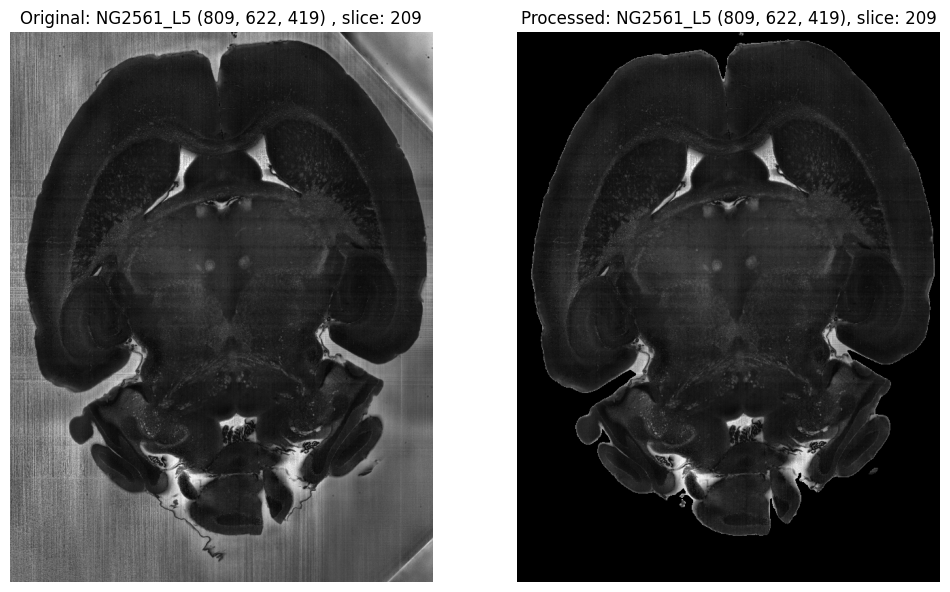

In [15]:
org_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG2561_L5_0000.nii.gz'
process_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/3d_lowres/NG2561_L5.nii.gz'

image_plot(org_path,process_path, 'NG2561_L5')

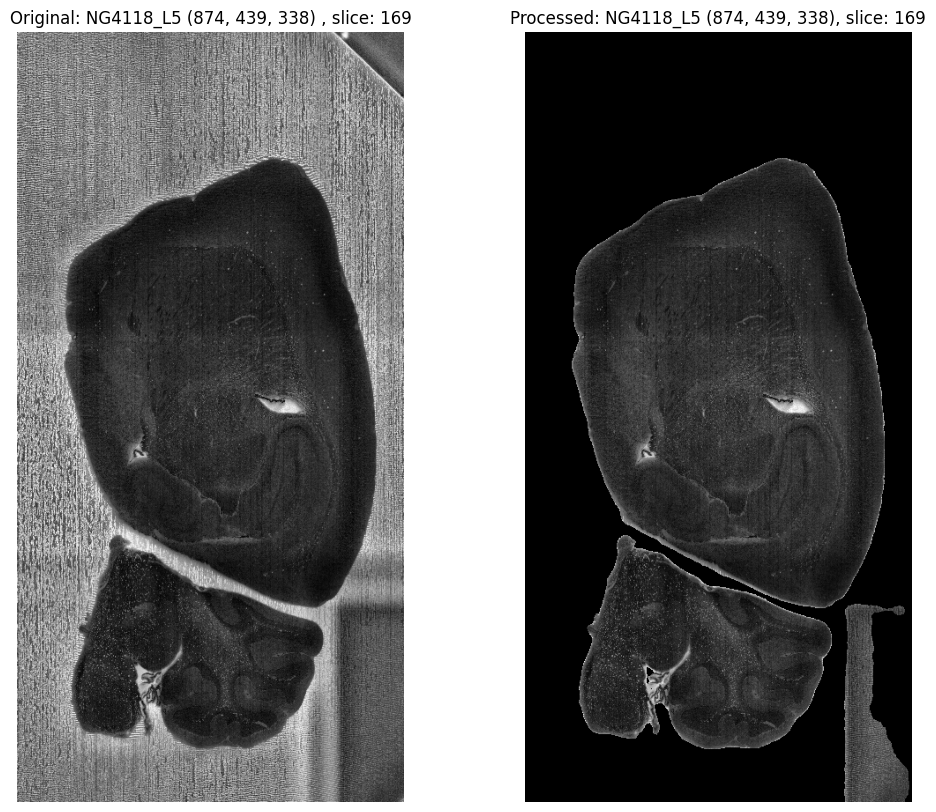

In [23]:
org_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG4118_L5_0000.nii.gz'
process_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/3d_lowres/NG4118_L5.nii.gz'

image_plot(org_path,process_path, 'NG4118_L5')

In [ ]:
org_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG4118_L5_0000.nii.gz'
process_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_Prediction_Results/Dataset001_Wdr47Kusss/3d_lowres/NG4118_L5.nii.gz'

image_plot(org_path,process_path, 'NG4118_L5')

In [28]:
org_path = '/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_test_data/NG4118_L5_0000.nii.gz'
process_path = 'dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4108_Segments_0000.nii.gz'

image_plot(org_path,process_path, 'NG4108_L5')

ValueError: operands could not be broadcast together with shapes (874,439,338) (584,1446,746) 

(2269, 3947, 2012)


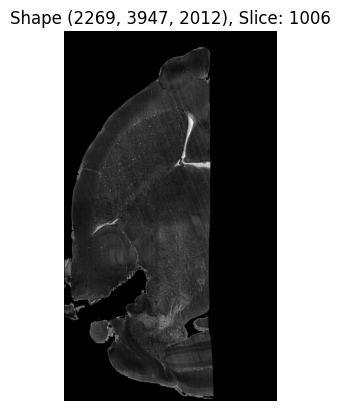

In [39]:

rc= '/work/shared/ngmm/3Dimage/Analysed_brains/HCFC1/NG4108_RC_masked.nrrd'
# Load the images
rc_data, rc_af = load_nrrd_file(rc)
print(rc_data.shape)
display_slice(rc_data)

(584, 1446, 746)


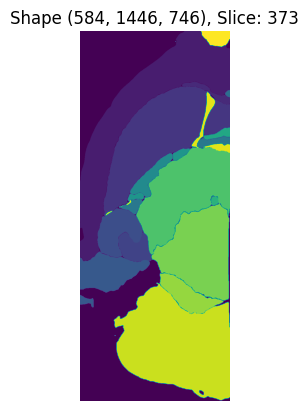

In [36]:
# Load the images
_data, _affine = load_nifti_file('dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4108_Segments_0000.nii.gz')
print(_data.shape)
display_slice(_data)